# EDA — Financial PhraseBank Corpus

Phase 1 · Financial News Radar (TFM)

Goal: understand the corpus before modelling. Covers class distribution, text-length analysis, duplicate detection, per-class examples, and a comparison across all four agreement-level configurations.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.data.corpus import load_corpus

FIGURES = ROOT / "reports" / "figures"
RESULTS = ROOT / "reports" / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"negative": "#d62728", "neutral": "#1f77b4", "positive": "#2ca02c"}
CLASS_ORDER = ["negative", "neutral", "positive"]
print("Paths OK. ROOT =", ROOT)


Paths OK. ROOT = C:\Users\rarra\Desktop\TFM


## 1 · Load corpus (sentences_allagree)

In [2]:
df = load_corpus("sentences_allagree")
print(f"Raw rows: {len(df)}")
print(df["label"].value_counts())
df.head(3)


Raw rows: 2264
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive


## 2 · Class distribution

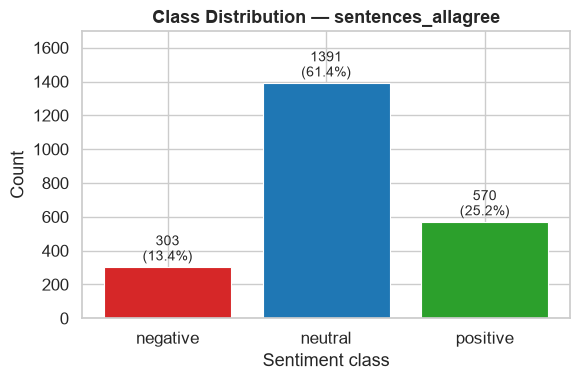

Figure saved.


In [3]:
vc = df["label"].value_counts().reindex(CLASS_ORDER)
pct = (vc / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(CLASS_ORDER, vc.values,
              color=[COLORS[c] for c in CLASS_ORDER], edgecolor="white", linewidth=0.8)
for bar, count, p in zip(bars, vc.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{count}\n({p}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution — sentences_allagree", fontweight="bold")
ax.set_xlabel("Sentiment class")
ax.set_ylabel("Count")
ax.set_ylim(0, vc.max() * 1.22)
ax.yaxis.set_major_locator(mticker.MultipleLocator(200))
plt.tight_layout()
fig.savefig(FIGURES / "class_distribution.png", dpi=150)
plt.show()
print("Figure saved.")


## 3 · Text-length distribution

In [4]:
df["n_words"] = df["text"].str.split().str.len()
df["n_chars"] = df["text"].str.len()

print("=== Word count stats (global) ===")
print(df["n_words"].describe().round(1).to_string())
print("\n=== Char count stats (global) ===")
print(df["n_chars"].describe().round(1).to_string())
print("\n=== Word count stats by class ===")
print(df.groupby("label")["n_words"].describe().round(1).to_string())


=== Word count stats (global) ===
count    2264.0
mean       22.4
std        10.1
min         2.0
25%        15.0
50%        21.0
75%        28.0
max        81.0

=== Char count stats (global) ===
count    2264.0
mean      122.0
std        56.2
min         9.0
25%        79.0
50%       111.0
75%       157.0
max       315.0

=== Word count stats by class ===
           count  mean   std  min   25%   50%   75%   max
label                                                    
negative   303.0  24.8  10.3  5.0  17.0  22.0  30.0  56.0
neutral   1391.0  20.9   9.7  2.0  14.0  19.0  26.0  81.0
positive   570.0  24.9  10.5  6.0  17.0  23.0  31.0  57.0


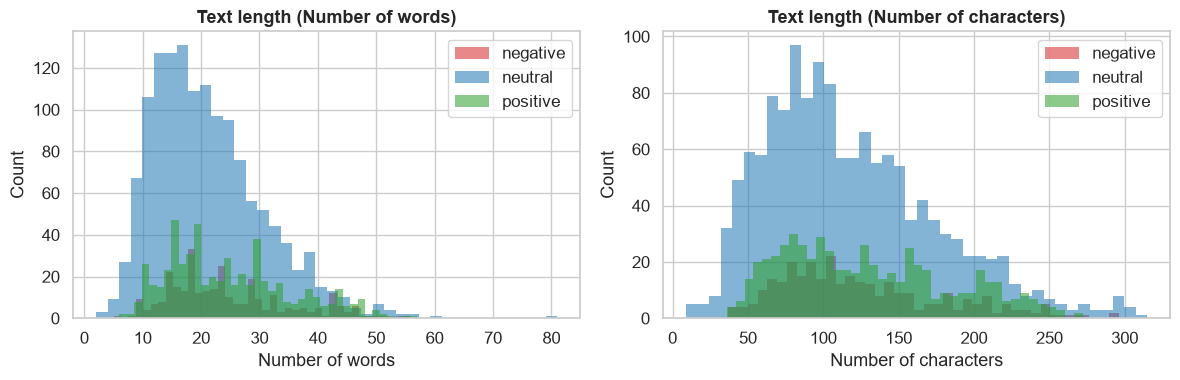

Figure saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for metric, ax, label in [
    ("n_words", axes[0], "Number of words"),
    ("n_chars",  axes[1], "Number of characters"),
]:
    for cls in CLASS_ORDER:
        subset = df.loc[df["label"] == cls, metric]
        ax.hist(subset, bins=40, alpha=0.55, color=COLORS[cls], label=cls, edgecolor="none")
    ax.set_title(f"Text length ({label})", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "text_length_distribution.png", dpi=150)
plt.show()
print("Figure saved.")


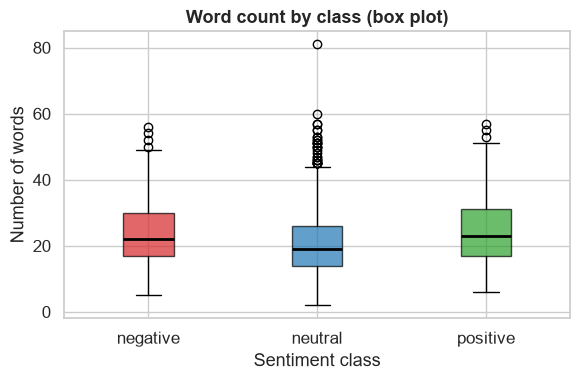

Figure saved.


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
data_by_class = [df.loc[df["label"] == cls, "n_words"].values for cls in CLASS_ORDER]
bp = ax.boxplot(data_by_class, tick_labels=CLASS_ORDER, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))
for patch, cls in zip(bp["boxes"], CLASS_ORDER):
    patch.set_facecolor(COLORS[cls])
    patch.set_alpha(0.7)
ax.set_title("Word count by class (box plot)", fontweight="bold")
ax.set_xlabel("Sentiment class")
ax.set_ylabel("Number of words")
plt.tight_layout()
fig.savefig(FIGURES / "text_length_boxplot.png", dpi=150)
plt.show()
print("Figure saved.")


## 4 · Duplicate and null check

In [7]:
n_total  = len(df)
n_nulls  = int(df["text"].isna().sum() + (df["text"].str.strip() == "").sum())
n_exact  = int(df.duplicated(subset="text").sum())
n_unique = n_total - n_exact

print(f"Total rows        : {n_total}")
print(f"Empty / null texts: {n_nulls}")
print(f"Exact duplicates  : {n_exact}")
print(f"Unique texts      : {n_unique}")


Total rows        : 2264
Empty / null texts: 0
Exact duplicates  : 5
Unique texts      : 2259


## 5 · Sample sentences per class

In [8]:
rng = np.random.default_rng(42)
for cls in CLASS_ORDER:
    subset = df[df["label"] == cls]
    idx = rng.choice(len(subset), size=min(4, len(subset)), replace=False)
    samples = subset.iloc[idx]["text"].tolist()
    print(f"\n--- {cls.upper()} ({len(subset)} total) ---")
    for i, s in enumerate(samples, 1):
        print(f"  [{i}] {s}")



--- NEGATIVE (303 total) ---
  [1] HELSINKI Thomson Financial - Shares closed little changed , with Cargotec and Huhtamaki dropping sharply on disappointing second-quarter reports .
  [2] Net sales of Finnish Sanoma Learning & Literature , of Finnish media group Sanoma , decreased by 3.6 % in January-June 2009 totalling EUR 162.8 mn , down from EUR 168.8 mn in the corresponding period in 2008 .
  [3] Net profit fell by almost half to +é 5.5 million from +é 9.4 million at the end of 2007 .
  [4] Exports of goods fell by 59 % , and imports by 16.7 % .

--- NEUTRAL (1391 total) ---
  [1] These include software development for internet and mobile telephone content , communications , value-added software , financial services , security applications , systems integration and electronics , '' EBRD informed .
  [2] UPM-Kymmene www.upm-kymmene.com produces magazine papers and newsprint , as well as fine and specialty papers , converting materials and wood products .
  [3] LKAB , headquartered 

## 6 · Configuration comparison (allagree / 75agree / 66agree / 50agree)

In [9]:
configs = [
    "sentences_allagree",
    "sentences_75agree",
    "sentences_66agree",
    "sentences_50agree",
]
config_stats = []
for cfg in configs:
    d = load_corpus(cfg)
    n_dup = d.duplicated(subset="text").sum()
    row = {"config": cfg, "total": len(d), "unique": len(d) - n_dup, "duplicates": int(n_dup)}
    for cls in CLASS_ORDER:
        cnt = int((d["label"] == cls).sum())
        row[cls] = cnt
        row[f"{cls}_pct"] = round(cnt / len(d) * 100, 1)
    config_stats.append(row)

cfg_df = pd.DataFrame(config_stats).set_index("config")
print(cfg_df[["total", "unique", "duplicates",
              "negative", "neutral", "positive",
              "negative_pct", "neutral_pct", "positive_pct"]].to_string())


                    total  unique  duplicates  negative  neutral  positive  negative_pct  neutral_pct  positive_pct
config                                                                                                             
sentences_allagree   2264    2259           5       303     1391       570          13.4         61.4          25.2
sentences_75agree    3453    3448           5       420     2146       887          12.2         62.1          25.7
sentences_66agree    4217    4211           6       514     2535      1168          12.2         60.1          27.7
sentences_50agree    4846    4838           8       604     2879      1363          12.5         59.4          28.1


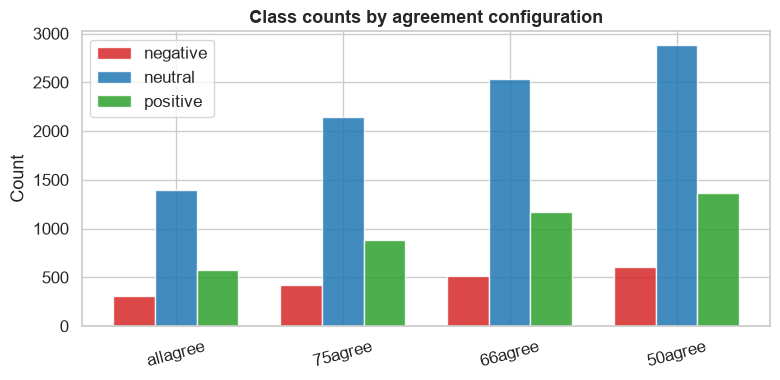

Figure saved.


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(configs))
width = 0.25
for i, cls in enumerate(CLASS_ORDER):
    ax.bar(x + i * width, cfg_df[cls].values, width,
           label=cls, color=COLORS[cls], alpha=0.85, edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("sentences_", "") for c in configs], rotation=15)
ax.set_title("Class counts by agreement configuration", fontweight="bold")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "config_comparison.png", dpi=150)
plt.show()
print("Figure saved.")


## 7 · Save numeric summary to reports/results/

In [11]:
summary = {
    "corpus_config": "sentences_allagree",
    "n_total": int(n_total),
    "n_unique": int(n_unique),
    "n_exact_duplicates": int(n_exact),
    "n_nulls_or_empty": int(n_nulls),
    "class_counts": {cls: int(vc[cls]) for cls in CLASS_ORDER},
    "class_pct":    {cls: float(pct[cls]) for cls in CLASS_ORDER},
    "word_count_global": {
        "mean":   round(float(df["n_words"].mean()), 1),
        "median": round(float(df["n_words"].median()), 1),
        "std":    round(float(df["n_words"].std()), 1),
        "min":    int(df["n_words"].min()),
        "max":    int(df["n_words"].max()),
    },
    "char_count_global": {
        "mean":   round(float(df["n_chars"].mean()), 1),
        "median": round(float(df["n_chars"].median()), 1),
        "std":    round(float(df["n_chars"].std()), 1),
        "min":    int(df["n_chars"].min()),
        "max":    int(df["n_chars"].max()),
    },
    "config_comparison": cfg_df[
        ["total", "unique", "duplicates", "negative", "neutral", "positive"]
    ].to_dict(orient="index"),
}

out_path = RESULTS / "eda_corpus.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Results saved to {out_path}")
core = {k: v for k, v in summary.items() if k != "config_comparison"}
print(json.dumps(core, indent=2))


Results saved to C:\Users\rarra\Desktop\TFM\reports\results\eda_corpus.json
{
  "corpus_config": "sentences_allagree",
  "n_total": 2264,
  "n_unique": 2259,
  "n_exact_duplicates": 5,
  "n_nulls_or_empty": 0,
  "class_counts": {
    "negative": 303,
    "neutral": 1391,
    "positive": 570
  },
  "class_pct": {
    "negative": 13.4,
    "neutral": 61.4,
    "positive": 25.2
  },
  "word_count_global": {
    "mean": 22.4,
    "median": 21.0,
    "std": 10.1,
    "min": 2,
    "max": 81
  },
  "char_count_global": {
    "mean": 122.0,
    "median": 111.0,
    "std": 56.2,
    "min": 9,
    "max": 315
  }
}
